In [14]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fit_trajectories import gof_trajectories

In [ ]:
traj120 = xr.load_dataarray("results/normalized_trajectories_120.nc")
traj24 = xr.load_dataarray("results/normalized_trajectories_24.nc")
genes = sorted(set(traj120.ensembl_gene_id.values) & set(traj24.ensembl_gene_id.values))

super_labels = xr.load_dataarray("results/superclusters_labels.nc").sel(ensembl_gene_id=genes)
super_labels

<xarray.DataArray 'cluster_label' (ensembl_gene_id: 19525)>
array([1, 3, 1, ..., 2, 3, 2])
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...

In [ ]:
subcluster = xr.DataArray(
    np.full(len(genes), -1, dtype=int),
    dims=("ensembl_gene_id",),
    coords={"ensembl_gene_id": genes},
    name="subcluster"
)

for sc in np.unique(super_labels.values):
    labels = xr.load_dataarray(f"results/supercluster_{sc}_labels.nc")
    subcluster.loc[dict(ensembl_gene_id=labels.ensembl_gene_id)] = labels


subcluster

<xarray.DataArray 'subcluster' (ensembl_gene_id: 19525)>
array([1, 1, 2, ..., 1, 1, 0])
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) <U18 'ENSDARG00000000001' ... 'ENSDARG...

In [ ]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
#ds = ds.sel(source = ['White et al.'])
mask = ds.tpm.max(dim=["time", "source"], skipna=True) >= 5
ds_filtered = ds.sel(ensembl_gene_id=mask)

trajectories120 = xr.load_dataarray("results/gene_trajectories_120.nc")

gof120 = gof_trajectories(ds_filtered, trajectories120)
gof120

  9%|▉         | 1940/22152 [00:06<01:03, 318.34it/s]


KeyboardInterrupt: 

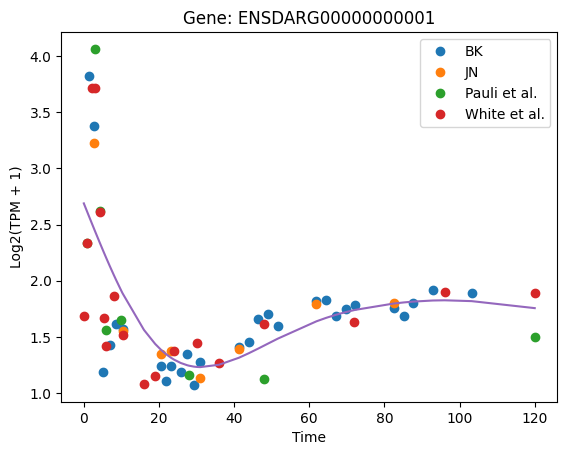

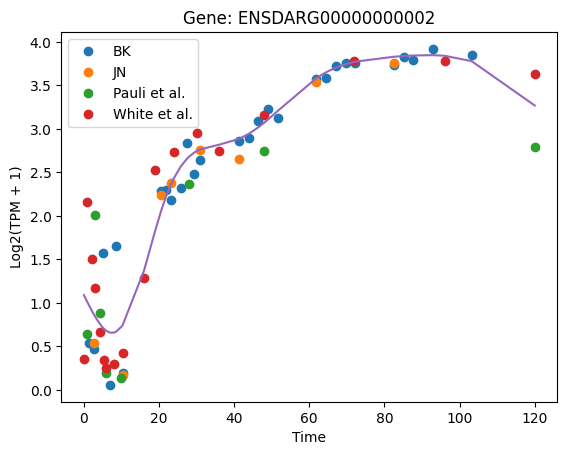

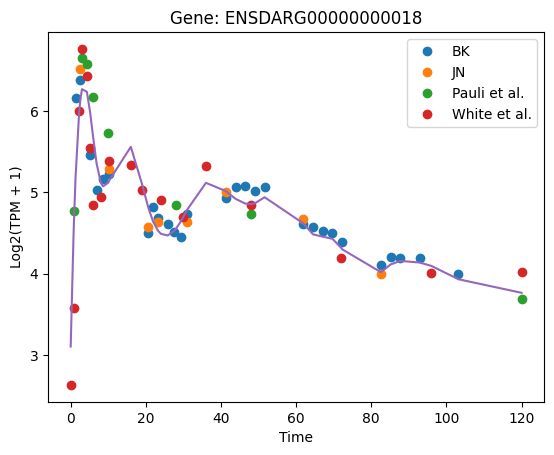

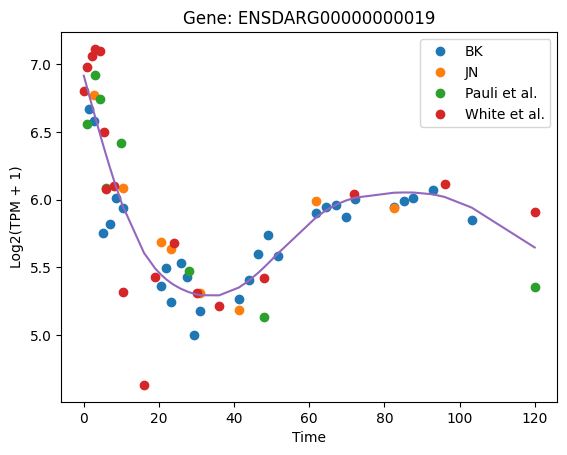

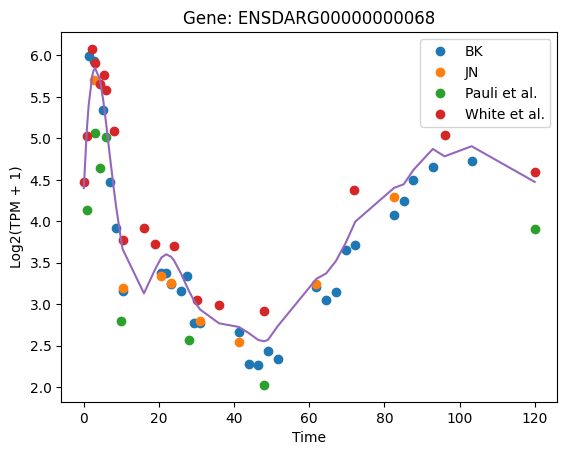

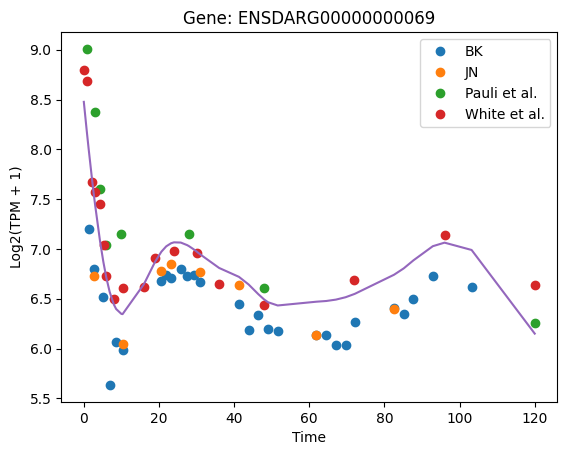

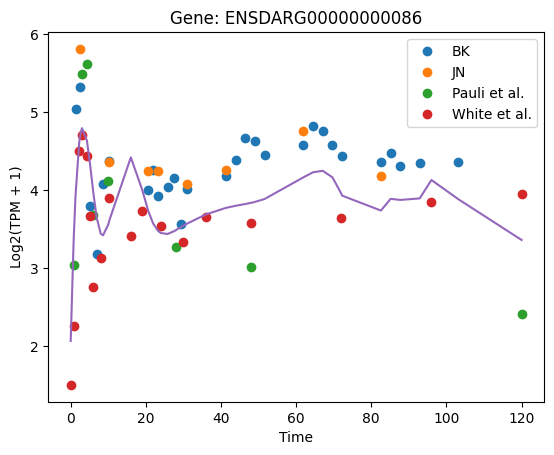

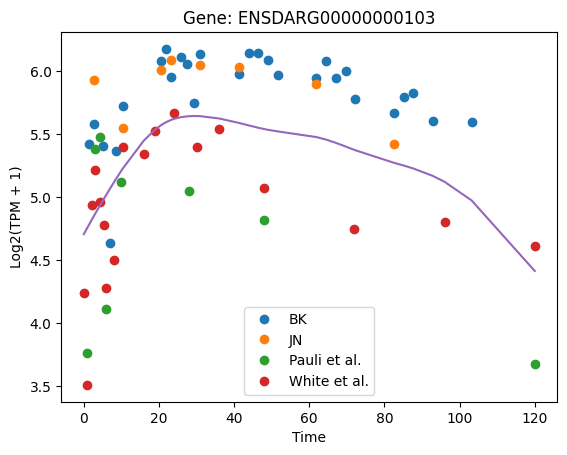

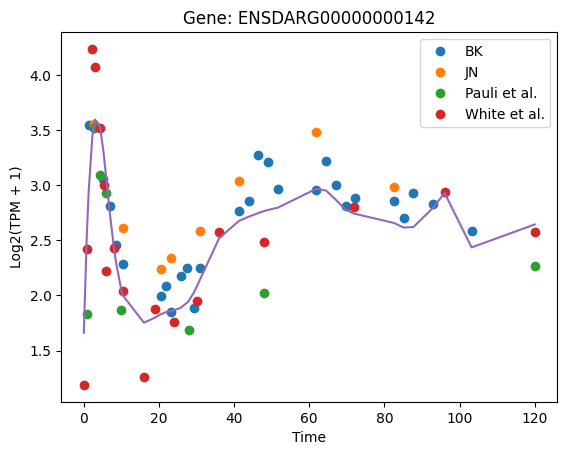

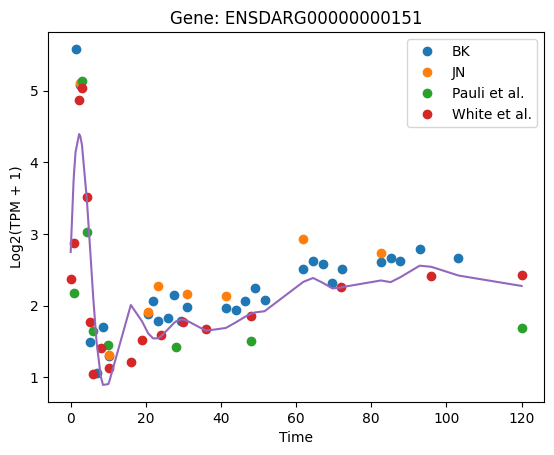

In [17]:
sc = ds.source.values
ds = np.log2(ds_filtered+1)

for g in ds_filtered.ensembl_gene_id.values[0:10]:
    y_true = ds.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = trajectories120.sel(ensembl_gene_id=g, drop=True)
    plt.figure()
    plt.plot(ds.time, y_true, marker="o", ls="", label=sc)
    plt.plot(ds.time, y_pred)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

In [ ]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
#ds = ds.sel(source = ['BK', 'White et al.'])
mask = ds.tpm.max(dim=["time", "source"], skipna=True) >= 5
ds_filtered = ds.sel(ensembl_gene_id=mask).sel(time=slice(0, 24))

trajectories12 = xr.load_dataarray("results/gene_trajectories_24.nc")

gof12 = gof_trajectories(ds_filtered, trajectories12)
gof12

100%|██████████| 22152/22152 [01:28<00:00, 250.14it/s]


,ensembl_gene_id,source,nrmse,accepted
0,ENSDARG00000000001,BK,0.134003,True
1,ENSDARG00000000002,BK,0.245809,False
2,ENSDARG00000000018,BK,0.205528,False
3,ENSDARG00000000019,BK,0.186510,False
4,ENSDARG00000000068,BK,0.109412,True
...,...,...,...,...
88603,ENSDARG00000117808,White et al.,0.157908,False
88604,ENSDARG00000117809,White et al.,0.115021,True
88605,ENSDARG00000117815,White et al.,0.183119,False
88606,ENSDARG00000117818,White et al.,0.280690,False


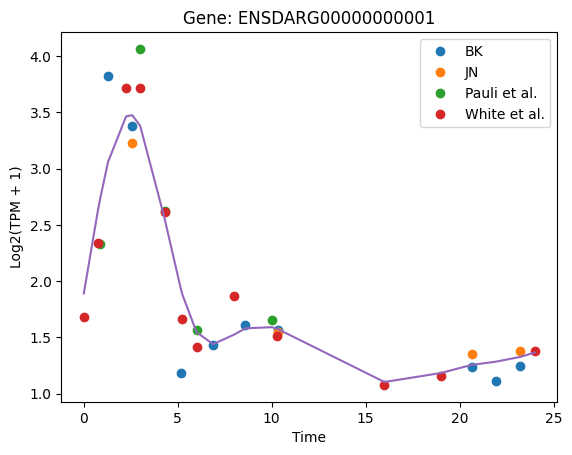

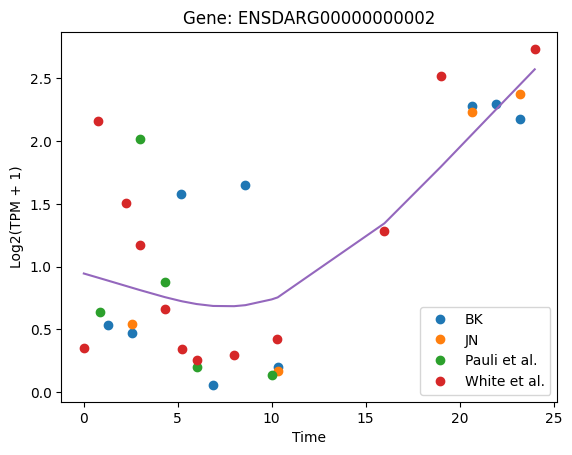

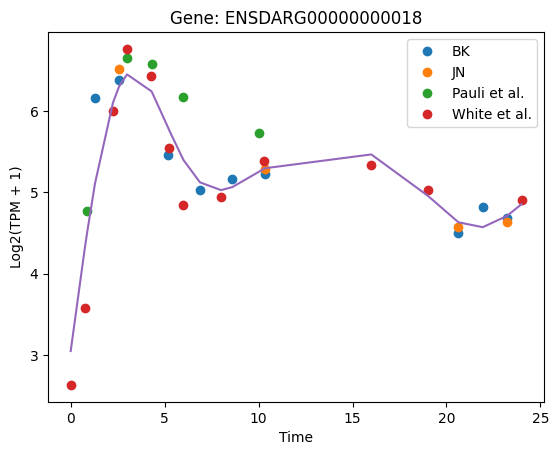

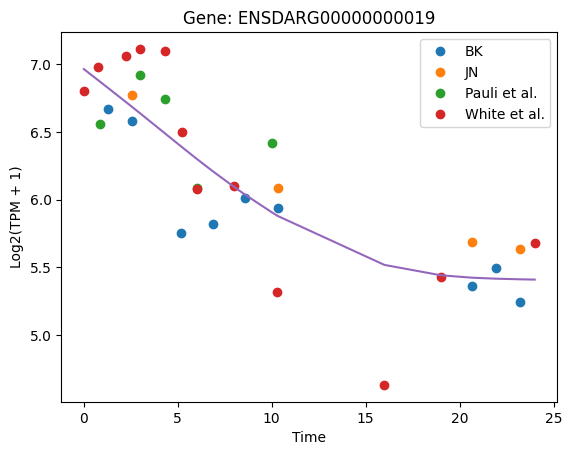

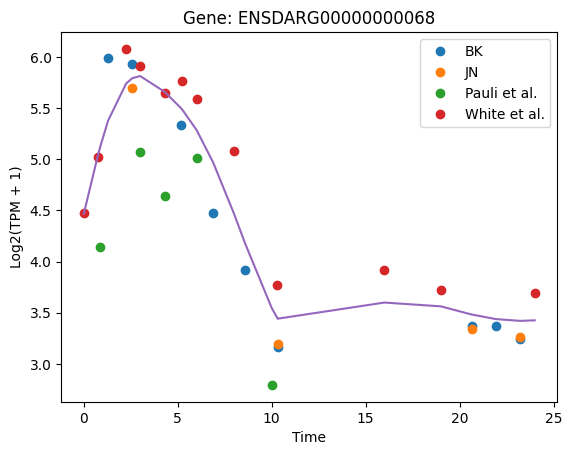

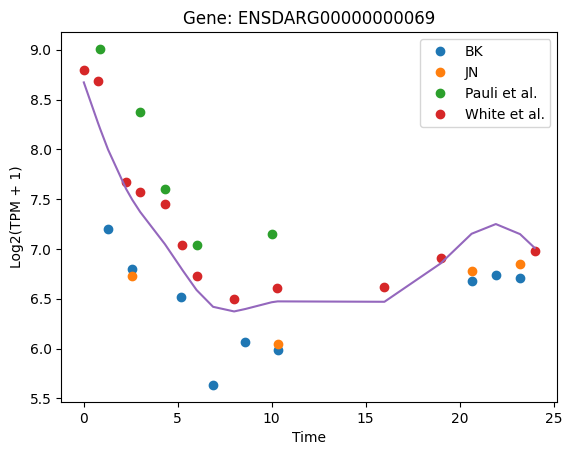

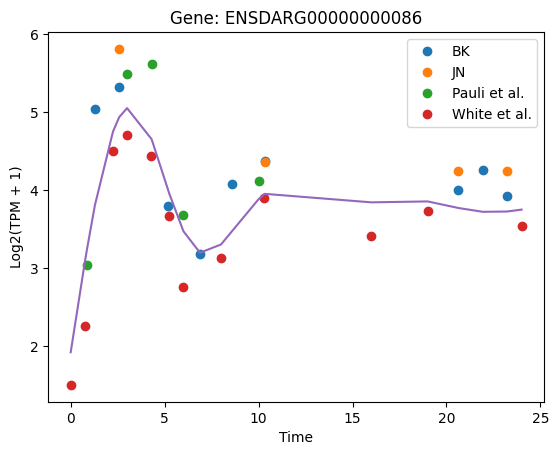

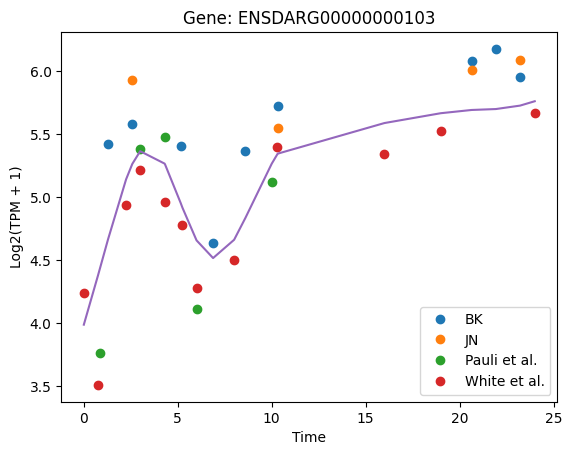

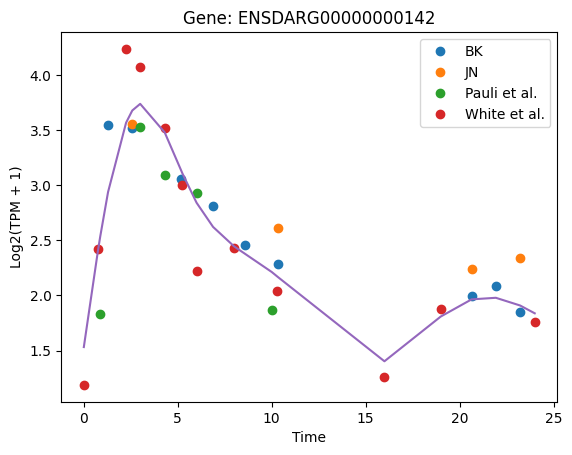

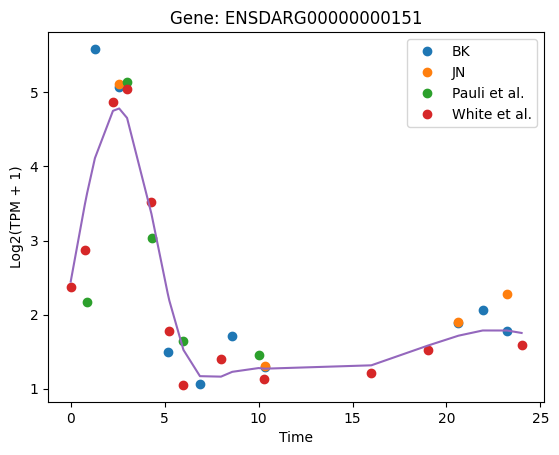

In [8]:
ds = np.log2(ds_filtered+1)
sc = ds.source.values

for g in ds.ensembl_gene_id.values[0:10]:
    y_true = ds.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = trajectories12.sel(ensembl_gene_id=g, drop=True)
    plt.figure()
    plt.plot(ds.time, y_true,  marker="o", ls="", label=sc)
    plt.plot(ds.time, y_pred, )
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

In [17]:
y =ds_filtered.sel(source="JN", drop=True).sel(ensembl_gene_id="ENSDARG00000000001", drop=True).tpm
y

<xarray.DataArray 'tpm' (time: 18)>
array([     nan,      nan,      nan,      nan,      nan, 8.357865,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 1.929165])
Coordinates:
  * time     (time) float64 0.0 0.75 0.875 1.29 2.25 ... 8.0 8.6 10.0 10.3 10.32

In [24]:
gof12[gof12["source"] == "JN"]

,ensembl_gene_id,source,nrmse
28725,ENSDARG00000000001,JN,0.186749
28726,ENSDARG00000000002,JN,0.879654
28727,ENSDARG00000000018,JN,0.136952
28728,ENSDARG00000000019,JN,0.297074
28729,ENSDARG00000000068,JN,0.083870
...,...,...,...
57445,ENSDARG00000117815,JN,0.078306
57446,ENSDARG00000117816,JN,0.288071
57447,ENSDARG00000117818,JN,41.756649
57448,ENSDARG00000117822,JN,7.157851


In [13]:
gof120.groupby("source").nrmse.mean()#.plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (120h)")

source
BK              0.184206
Pauli et al.    0.286689
White et al.    0.192311
Name: nrmse, dtype: float64

In [14]:
gof12.groupby("source").nrmse.mean()#.plot.barh(color="blue", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (12h)")

source
BK              0.369180
Pauli et al.    0.501758
White et al.    0.292029
Name: nrmse, dtype: float64

### Sankey diagramm

In [ ]:
from pySankey.sankey import sankey

def cluster_agreement(ds1, ds2, algo1, algo2):

    df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster":ds1.cluster_label.values})
    df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster":ds2.cluster.values})

    df1["cluster2"] = df2["cluster"]
    df1["agreement"] = (df1["cluster"] == df1["cluster2"])
    df = df1.dropna(subset=["cluster", "cluster2"])
    df = df.sort_values(["cluster", "cluster2"], ascending=False)

    left_labels = list(sorted(df["cluster"].dropna().unique()))
    right_labels = list(sorted(df["cluster2"].dropna().unique()))

    sankey(left=df["cluster"], right=df["cluster2"], 
           aspect=20, fontsize=12,
           figure_name=f"clustering/cluster_agreement_{algo1}_{algo2}")

    # Get current figure
    fig = plt.gcf()
    fig.set_size_inches(6, 6)
    fig.set_facecolor("w")
    plt.title(f"Cluster changes ({algo1} → {algo2})")
    #fig.savefig(f"clustering/cluster_agreement_{algo1}_algo2.png", bbox_inches="tight", dpi=300)

    agree = df["agreement"].sum() / len(df) * 100
    print(f"Cluster agreement: {agree:.2f} %")

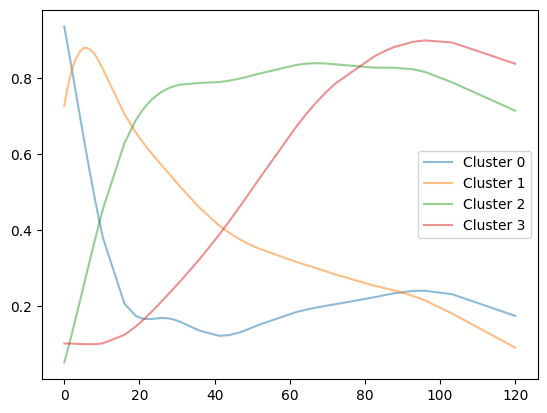

In [ ]:
fuzzy_cntr = xr.load_dataarray("results/superclusters_centers.nc")
peak = fuzzy_cntr.values.argmax(axis=1)
fuzzy_cntr = fuzzy_cntr.isel(cluster=np.argsort(peak))

for c in range(fuzzy_cntr.shape[0]):
    plt.plot(fuzzy_cntr.time, fuzzy_cntr[c, :], alpha=0.5, label=f"Cluster {c}")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'clustering/cluster_agreement_fuzzy_cmeans_hier_fuzzy_cmeans.png'

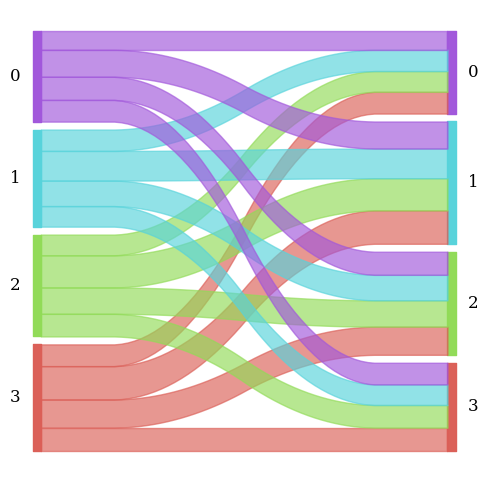

In [ ]:
algo1 = "fuzzy_cmeans_hier"
algo2 = "fuzzy_cmeans"

ds1 = xr.load_dataset("results/superclusters_labels.nc")
ds2 = ds2 = xr.load_dataset(f"C:/Users/mgrho/Hiwi_polyA/clustering/fuzzy_c-means_clustered_ds_all.nc")

cluster_agreement(ds1, ds2, algo1, algo2)